# Sorting Algorithms - Implementation and Performance Analysis

A comparison of 5 classic sorting algorithms implemented from scratch in Python.
Each algorithm is tested on random arrays of increasing sizes to visualize
how their execution time grows with input size.

In [6]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from src.algorithms import bubble_sort, selection_sort, insertion_sort, merge_sort, quick_sort
from src.benchmarks import run_benchmark, ALGORITHMS

## Correctness Check

Verify that all algorithms produce the same sorted output.

In [7]:
test_array = [64, 34, 25, 12, 22, 11, 90, 3, 77, 45]
print(f"Original:       {test_array}\n")

for name, func in ALGORITHMS.items():
    result = func(test_array)
    print(f"{name:<20} {result}")

Original:       [64, 34, 25, 12, 22, 11, 90, 3, 77, 45]

Bubble Sort          [3, 11, 12, 22, 25, 34, 45, 64, 77, 90]
Selection Sort       [3, 11, 12, 22, 25, 34, 45, 64, 77, 90]
Insertion Sort       [3, 11, 12, 22, 25, 34, 45, 64, 77, 90]
Merge Sort           [3, 11, 12, 22, 25, 34, 45, 64, 77, 90]
Quick Sort           [3, 11, 12, 22, 25, 34, 45, 64, 77, 90]


## Performance Benchmark

Each algorithm is tested on random arrays of sizes from 100 to 2000 elements.
Every test is repeated 3 times and the average is recorded.

In [8]:
sizes = [100, 250, 500, 750, 1000, 1500, 2000]
results = run_benchmark(sizes, runs=3)

df = pd.DataFrame(results, index=sizes)
df.index.name = "Array Size"
df.columns.name = "Algorithm"
print("Execution time (ms):\n")
print(df.to_string())

Testing size: 100
Testing size: 250
Testing size: 500
Testing size: 750
Testing size: 1000
Testing size: 1500
Testing size: 2000
Execution time (ms):

Algorithm   Bubble Sort  Selection Sort  Insertion Sort  Merge Sort  Quick Sort
Array Size                                                                     
100              0.6179          0.3801          0.3397      0.2404      0.2419
250              3.7284          1.9339          1.7854      0.5478      0.4873
500             16.0177         11.5121          8.7784      1.6550      1.1548
750             35.4437         18.4049         19.0683      1.8676      1.6548
1000            70.0249         35.2541         34.6227      2.7680      2.4080
1500           161.2824         75.7070         77.9379      4.7042      3.6505
2000           301.5075        146.0598        139.7900      5.4394      4.6127


## Performance Visualization

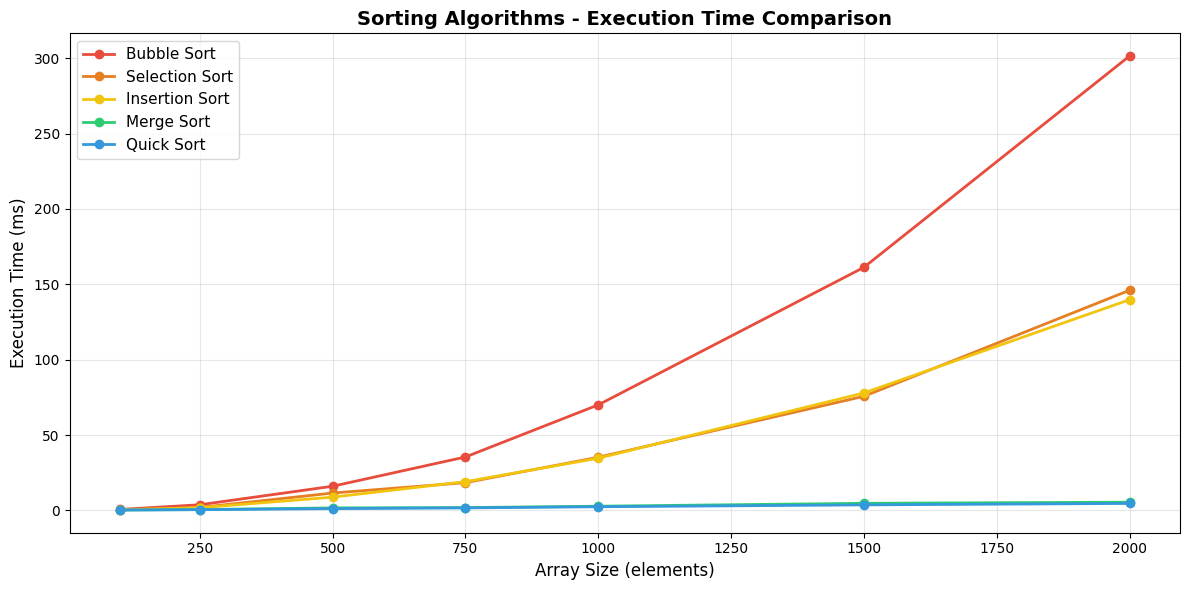

Chart saved to images/performance_comparison.png


In [9]:
colors = {
    "Bubble Sort":    "#e74c3c",
    "Selection Sort": "#e67e22",
    "Insertion Sort": "#f1c40f",
    "Merge Sort":     "#2ecc71",
    "Quick Sort":     "#3498db"
}

plt.figure(figsize=(12, 6))

for name, times in results.items():
    plt.plot(sizes, times, marker="o", linewidth=2,
             color=colors[name], label=name)

plt.title("Sorting Algorithms - Execution Time Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Array Size (elements)", fontsize=12)
plt.ylabel("Execution Time (ms)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/performance_comparison.png", dpi=150)
plt.show()
print("Chart saved to images/performance_comparison.png")

## O(n²) vs O(n log n) — Zoom in on efficient algorithms

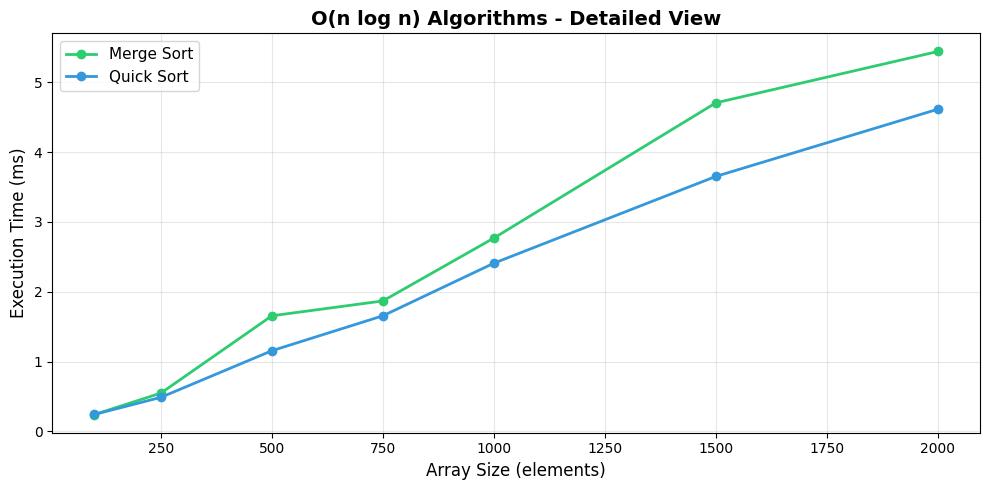

In [10]:
efficient = ["Merge Sort", "Quick Sort"]

plt.figure(figsize=(10, 5))

for name in efficient:
    plt.plot(sizes, results[name], marker="o", linewidth=2,
             color=colors[name], label=name)

plt.title("O(n log n) Algorithms - Detailed View", fontsize=14, fontweight="bold")
plt.xlabel("Array Size (elements)", fontsize=12)
plt.ylabel("Execution Time (ms)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/efficient_algorithms.png", dpi=150)
plt.show()

## Complexity Summary

| Algorithm      | Best Case  | Average Case | Worst Case | Space   |
|----------------|------------|--------------|------------|---------|
| Bubble Sort    | O(n)       | O(n²)        | O(n²)      | O(1)    |
| Selection Sort | O(n²)      | O(n²)        | O(n²)      | O(1)    |
| Insertion Sort | O(n)       | O(n²)        | O(n²)      | O(1)    |
| Merge Sort     | O(n log n) | O(n log n)   | O(n log n) | O(n)    |
| Quick Sort     | O(n log n) | O(n log n)   | O(n²)      | O(log n)|